In [ ]:
!pip install -q chromadb langchain sentence-transformers PyPDF2 tqdm numpy

In [ ]:
# Import libraries
import os, re, pickle, hashlib
from typing import List, Tuple
from dataclasses import dataclass
from tqdm import tqdm
import numpy as np
import PyPDF2
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics.pairwise import cosine_similarity
import chromadb
from chromadb.config import Settings

In [ ]:
# ---------------------------
# Configuration
# ---------------------------
CHROMA_DIR = "/content/chroma_db"
PDF_PATH = "/content/Principal-Sample-Life-Insurance-Policy.pdf" # Corrected PDF path
CACHE_DIR = "/content/cache"
EMBED_MODEL_ST = "all-MiniLM-L6-v2"
CROSS_ENCODER_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"


os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(CHROMA_DIR, exist_ok=True)

In [ ]:
# ---------------------------
# Utilities
# ---------------------------


def sha1(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()


def save_pickle(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)


def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

In [ ]:
# ---------------------------
# PDF Extraction
# ---------------------------


def extract_text_from_pdf(path: str) -> str:
    reader = PyPDF2.PdfReader(path)
    pages = [p.extract_text() or "" for p in reader.pages]
    return "\n\n".join(pages)

In [ ]:
# ---------------------------
# Cleaning + Chunking
# ---------------------------


def clean_text(text: str) -> str:
    text = text.replace('\r', '\n')
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"[ \t]+", " ", text)
    return text.strip()


def chunk_by_chars(text: str, chunk_size: int = 800, overlap: int = 200) -> List[str]:
    chunks = []
    i = 0
    n = len(text)
    while i < n:
        end = min(n, i + chunk_size)
        chunks.append(text[i:end].strip())
        i += chunk_size - overlap
    return chunks

In [ ]:
# ---------------------------
# Embeddings
# ---------------------------


def get_sentence_transformer_model(name: str = EMBED_MODEL_ST):
    return SentenceTransformer(name)


def embed_texts_st(model, texts: List[str]) -> np.ndarray:
    return model.encode(texts, show_progress_bar=True, convert_to_numpy=True)

In [ ]:
# ---------------------------
# Embeddings
# ---------------------------


def get_sentence_transformer_model(name: str = EMBED_MODEL_ST):
    return SentenceTransformer(name)


def embed_texts_st(model, texts: List[str]) -> np.ndarray:
    return model.encode(texts, show_progress_bar=True, convert_to_numpy=True)

In [ ]:
# ---------------------------
# ChromaDB
# ---------------------------


def init_chroma(persist_directory: str = CHROMA_DIR):
    return chromadb.PersistentClient(path=persist_directory)


def create_or_reset_collection(client, name: str = "policy_collection"):
    try:
        client.delete_collection(name)
    except Exception:
        pass
    return client.create_collection(name)

In [ ]:
# ---------------------------
# Re-ranker
# ---------------------------


def init_reranker(model_name: str = CROSS_ENCODER_MODEL):
    return CrossEncoder(model_name)


def rerank(reranker, query: str, candidate_texts: List[str]) -> List[Tuple[int, float]]:
    pairs = [[query, c] for c in candidate_texts]
    scores = reranker.predict(pairs)
    ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
    return ranked

In [ ]:
# ---------------------------
# Generation Layer
# ---------------------------


def generate_answer_basic(question: str, snippets: List[str]) -> str:
    if not snippets:
        return "The policy does not specify this."
    return f"Based on the policy snippet: {snippets[0][:400]}... (see snippet 1)"

In [ ]:
# ---------------------------
# Full Pipeline
# ---------------------------
@dataclass
class MRHelpmateColab:
    pdf_path: str
    chroma_dir: str = CHROMA_DIR
    st_model_name: str = EMBED_MODEL_ST
    cross_encoder_name: str = CROSS_ENCODER_MODEL


    def __post_init__(self):
        self.client = init_chroma(self.chroma_dir)
        self.collection = create_or_reset_collection(self.client)
        self.st_model = get_sentence_transformer_model(self.st_model_name)
        self.reranker = init_reranker(self.cross_encoder_name)


    def build_index(self, chunk_strategy: str = 'chars', chunk_size: int = 800, overlap: int = 200):
        text = extract_text_from_pdf(self.pdf_path)
        text = clean_text(text)
        if chunk_strategy == 'chars':
            chunks = chunk_by_chars(text, chunk_size=chunk_size, overlap=overlap)
        else:
            # Assuming chunk_by_sentences is defined elsewhere or will be added
            # For now, this branch is illustrative and might require further definition
            # For the current context, we'll proceed with chars strategy
            chunks = chunk_by_chars(text, chunk_size=chunk_size, overlap=overlap) # Placeholder if chunk_by_sentences is not defined

        ids = [sha1(c) for c in chunks]
        metadatas = [{'source': self.pdf_path, 'chunk_id': i} for i, _ in enumerate(chunks)]
        embedding_vectors = embed_texts_st(self.st_model, chunks)


        self.collection.add(ids=ids, documents=chunks, metadatas=metadatas, embeddings=embedding_vectors.tolist())
        self.chunks = chunks
        print(f"Indexed {len(chunks)} chunks")


    def cached_search(self, query: str, k: int = 10):
        key = os.path.join(CACHE_DIR, sha1(query) + '.pkl')
        if os.path.exists(key):
            return load_pickle(key)
        q_vec = self.st_model.encode(query)
        results = self.collection.query(query_embeddings=[q_vec.tolist()], n_results=k)
        save_pickle(results, key)
        return results


    def search_and_rerank(self, query: str, top_k: int = 10, rerank_k: int = 5):
        res = self.cached_search(query, k=top_k)
        docs = res['documents'][0]
        candidates = docs[:rerank_k]
        ranked = rerank(self.reranker, query, candidates)
        ranked_texts = [(candidates[i], score) for i, score in ranked]
        return ranked_texts, docs


    def answer_query(self, question: str, top_k: int = 10, rerank_k: int = 5):
        ranked_texts, docs = self.search_and_rerank(question, top_k=top_k, rerank_k=rerank_k)
        snippets = [t for t, s in ranked_texts[:3]]
        return generate_answer_basic(question, snippets)

In [ ]:
# ------------------------------
# Initialize
# ------------------------------
mr = MRHelpmateColab(pdf_path=PDF_PATH)
mr.build_index()

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Indexed 173 chunks


In [ ]:
# ------------------------------
# Queries
# ------------------------------
queries = [
    "What is the eligibility criteria for group member life insurance?",
    "How much is the death benefit for an accidental death under the policy?",
    "What is the procedure for filing a claim and required documentation?"
]



===== QUERY 1 =====
Query: What is the eligibility criteria for group member life insurance?

--- Search Layer - Top 3 Chunks ---
Chunk 1 score: 7.1126
- Eligibility 
 Article 1 - Member Life Insurance 
 
A person will be eligible for Member Life Insurance on the date the person completes 30 
consecutive days of continuous Active Work with the Policyholder as a Member. In no circumstance will a person be eligible for Member Life Insurance under thi ...

Chunk 2 score: 3.2949
e. 
 
Article 3 - Policyholder Eligibility Requirements 
 
To be an eligible group and to remain an eligible group, the Policyholder must: 

 
 
 
 
 
This policy has been updated effective January 1, 2014 
 
 
PART II - POLICY ADMINISTRATION 
GC 6003 Section A - Contract, Page 2 
 
a. be actively e ...

Chunk 3 score: 2.1803
life insurance only. No disabilit y or other benefits will be 
included. 
(3) The policy will be on one of the forms, other than term insurance, then issued by The 
Principal to persons in th

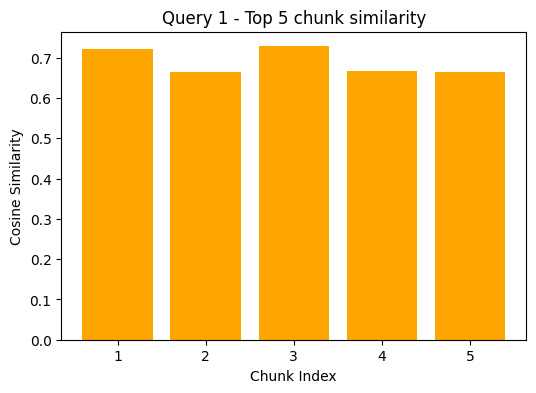


===== QUERY 2 =====
Query: How much is the death benefit for an accidental death under the policy?

--- Search Layer - Top 3 Chunks ---
Chunk 1 score: 1.2684
benefit in excess of 50% of the Member's 
Scheduled Benefit amount, the Dependent will be given the highest amount available, not to exceed 50%. 
 
Article 2 - Death Benefits Payable 
 
If a Dependent dies while insured for Dependent Life Insurance under this Group Policy, The 
Principal will pay th ...

Chunk 2 score: 0.2062
y; and 
 b. the injury must be through external, violent, and accidental means; and 
 c. the injury must be the direct and sole cause of a loss listed in this Section B, Article 3; and 
 d. the loss must occur within 365 days of the injury; and 
 e. the limitations listed in this Section B, Article  ...

Chunk 3 score: 0.0510
s different than the Scheduled Benefit, the approved amount will 
apply. 
 
For the age(s) shown below, the amount of a Member's insurance will be the percentage of the Scheduled Benefi

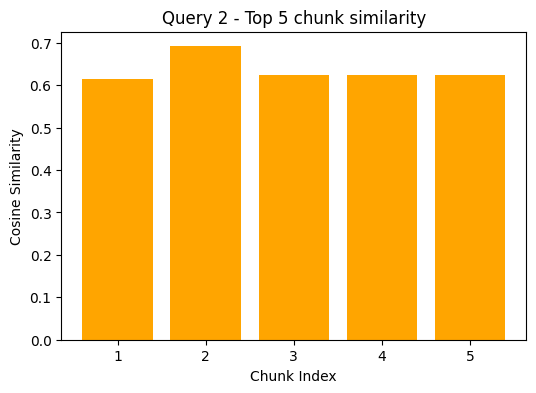


===== QUERY 3 =====
Query: What is the procedure for filing a claim and required documentation?

--- Search Layer - Top 3 Chunks ---
Chunk 1 score: -1.8857
s Group Policy upon submitting, within the time specified below for filing proof of loss, W ritten proof covering the 
occurrence, character, and extent of the loss. 
 
Article 3 - Proof of Loss 
 
Written proof of loss must be sent to The Principal within 90 days after the date of the loss. 
Proof  ...

Chunk 2 score: -2.2910
ten notification will be sent to the claimant regarding the extension. After exhaustion of the formal appeal process, the claimant may request an additional appeal. However, this appeal is voluntary and does not need to be filed before asserting rights to legal action. 
 For purposes of this section ...

Chunk 3 score: -2.9719
claimant may request an appeal of a claim denial by Written request to The Principal within 
180 days of receipt of notice of the denial. The Principal will make a full and fair review 

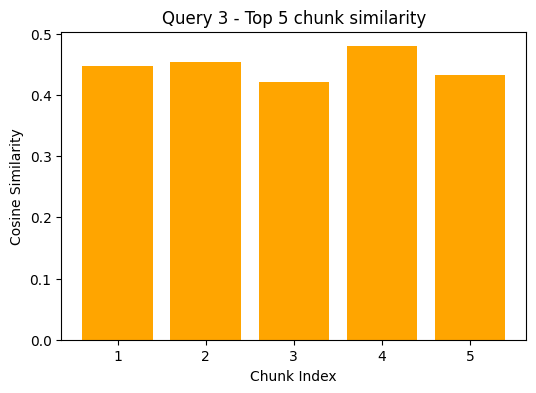

In [ ]:
# ------------------------------
# Run queries one by one
# ------------------------------
for i, query in enumerate(queries, 1):
    print(f"\n===== QUERY {i} =====")
    print("Query:", query)

    # Search Layer: top-3 chunks
    ranked_texts, docs = mr.search_and_rerank(query)
    print("\n--- Search Layer - Top 3 Chunks ---")
    for j, (chunk, score) in enumerate(ranked_texts[:3]):
        print(f"Chunk {j+1} score: {score:.4f}")
        print(chunk[:300], "...\n")  # show first 300 chars for readability

    # Generation Layer: answer
    answer = mr.answer_query(query)
    print("--- Generation Layer - Answer ---")
    print(answer)

    # Optional: similarity bar chart
    top_chunks = [c for c, s in ranked_texts[:5]]
    q_vec = mr.st_model.encode([query])
    top_vecs = mr.st_model.encode(top_chunks)
    sims = cosine_similarity(q_vec, top_vecs)[0]

    plt.figure(figsize=(6,4))
    plt.bar(range(1,len(sims)+1), sims, color='orange')
    plt.title(f"Query {i} - Top 5 chunk similarity")
    plt.xlabel("Chunk Index")
    plt.ylabel("Cosine Similarity")
    plt.show()

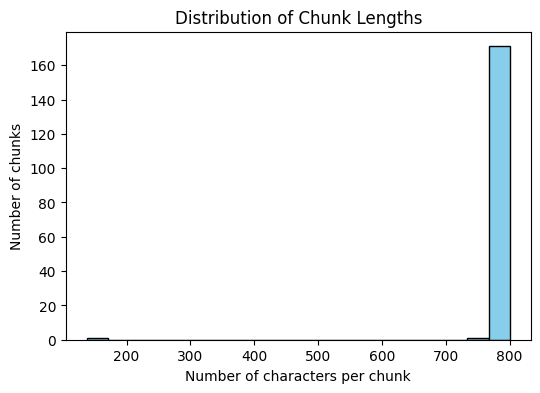

In [ ]:
# ------------------------------
# Chunk length distribution
# ------------------------------
chunk_lengths = [len(c) for c in mr.chunks]
plt.figure(figsize=(6,4))
plt.hist(chunk_lengths, bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Chunk Lengths")
plt.xlabel("Number of characters per chunk")
plt.ylabel("Number of chunks")
plt.show()


In [ ]:
# --------------------------
# Seperate deatailed: Query 1
# --------------------------
query = "What is the eligibility criteria for group member life insurance?"

# Search Layer: top-3 chunks
ranked_texts, docs = mr.search_and_rerank(query)
print("=== Search Layer - Top 3 chunks ===")
for j, (chunk, score) in enumerate(ranked_texts[:3]):
    print(f"Chunk {j+1} score: {score:.4f}")
    print(chunk[:300], "...\n")  # first 300 chars for readability

# Generation Layer: answer
answer = mr.answer_query(query)
print("=== Generation Layer - Answer ===")
print(answer)


=== Search Layer - Top 3 chunks ===
Chunk 1 score: 7.1126
- Eligibility 
 Article 1 - Member Life Insurance 
 
A person will be eligible for Member Life Insurance on the date the person completes 30 
consecutive days of continuous Active Work with the Policyholder as a Member. In no circumstance will a person be eligible for Member Life Insurance under thi ...

Chunk 2 score: 3.2949
e. 
 
Article 3 - Policyholder Eligibility Requirements 
 
To be an eligible group and to remain an eligible group, the Policyholder must: 

 
 
 
 
 
This policy has been updated effective January 1, 2014 
 
 
PART II - POLICY ADMINISTRATION 
GC 6003 Section A - Contract, Page 2 
 
a. be actively e ...

Chunk 3 score: 2.1803
life insurance only. No disabilit y or other benefits will be 
included. 
(3) The policy will be on one of the forms, other than term insurance, then issued by The 
Principal to persons in the risk class to which the Member belongs on the individual policy's effective date. 
(4) Premiu

In [ ]:

# --------------------------
# Seperate deatailed: QUERY 2
# --------------------------
query2 = "How much is the death benefit for an accidental death under the policy?"

# Search Layer: top-3 chunks
ranked_texts2, docs2 = mr.search_and_rerank(query2)
print("=== QUERY 2: Search Layer - Top 3 chunks ===")
for j, (chunk, score) in enumerate(ranked_texts2[:3]):
    print(f"Chunk {j+1} score: {score:.4f}")
    print(chunk[:300], "...\n")

# Generation Layer: answer
answer2 = mr.answer_query(query2)
print("=== QUERY 2: Generation Layer - Answer ===")
print(answer2)

=== QUERY 2: Search Layer - Top 3 chunks ===
Chunk 1 score: 1.2684
benefit in excess of 50% of the Member's 
Scheduled Benefit amount, the Dependent will be given the highest amount available, not to exceed 50%. 
 
Article 2 - Death Benefits Payable 
 
If a Dependent dies while insured for Dependent Life Insurance under this Group Policy, The 
Principal will pay th ...

Chunk 2 score: 0.2062
y; and 
 b. the injury must be through external, violent, and accidental means; and 
 c. the injury must be the direct and sole cause of a loss listed in this Section B, Article 3; and 
 d. the loss must occur within 365 days of the injury; and 
 e. the limitations listed in this Section B, Article  ...

Chunk 3 score: 0.0510
s different than the Scheduled Benefit, the approved amount will 
apply. 
 
For the age(s) shown below, the amount of a Member's insurance will be the percentage of the Scheduled Benefit (or approved amount, if a pplicable) as shown below. 
 
 
 Age % of Scheduled Benefit (or 

In [ ]:
# --------------------------
# Seperate deatailed: QUERY 3
# --------------------------
query3 = "What is the procedure for filing a claim and required documentation?"

# Search Layer: top-3 chunks
ranked_texts3, docs3 = mr.search_and_rerank(query3)
print("=== QUERY 3: Search Layer - Top 3 chunks ===")
for j, (chunk, score) in enumerate(ranked_texts3[:3]):
    print(f"Chunk {j+1} score: {score:.4f}")
    print(chunk[:300], "...\n")

# Generation Layer: answer
answer3 = mr.answer_query(query3)
print("=== QUERY 3: Generation Layer - Answer ===")
print(answer3)

=== QUERY 3: Search Layer - Top 3 chunks ===
Chunk 1 score: -1.8857
s Group Policy upon submitting, within the time specified below for filing proof of loss, W ritten proof covering the 
occurrence, character, and extent of the loss. 
 
Article 3 - Proof of Loss 
 
Written proof of loss must be sent to The Principal within 90 days after the date of the loss. 
Proof  ...

Chunk 2 score: -2.2910
ten notification will be sent to the claimant regarding the extension. After exhaustion of the formal appeal process, the claimant may request an additional appeal. However, this appeal is voluntary and does not need to be filed before asserting rights to legal action. 
 For purposes of this section ...

Chunk 3 score: -2.9719
claimant may request an appeal of a claim denial by Written request to The Principal within 
180 days of receipt of notice of the denial. The Principal will make a full and fair review of the claim. The Principal may require a dditional information to make the review. The P